In [65]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [90]:
!pip install scikit-learn
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [67]:
df= pd.read_csv("MagicTelescope.csv")

In [68]:
df.head()

,id,ID,fLength:,fWidth:,fSize:,fConc:,fConc1:,fAsym:,fM3Long:,fM3Trans:,fAlpha:,fDist:,class:
0,1,1,28.7967,16.0021,2.6449,0.3918,0.1982,27.7004,22.0110,-8.2027,40.0920,81.8828,g
1,2,2,31.6036,11.7235,2.5185,0.5303,0.3773,26.2722,23.8238,-9.9574,6.3609,205.2610,g
2,3,3,162.0520,136.0310,4.0612,0.0374,0.0187,116.7410,-64.8580,-45.2160,76.9600,256.7880,g
3,4,4,23.8172,9.5728,2.3385,0.6147,0.3922,27.2107,-6.4633,-7.1513,10.4490,116.7370,g
4,5,5,75.1362,30.9205,3.1611,0.3168,0.1832,-5.5277,28.5525,21.8393,4.6480,356.4620,g


In [69]:
df =df.drop(["id", "ID"], axis=1)

In [70]:
df.columns = ["fLength", "fWidth", "fSize", "fConc", "fConc1", "fAsym", "fM3Long", "fM3Trans", "fAlpha", "fDist", "class"]

In [71]:
cols = df.columns

In [72]:
cols

Index(['fLength', 'fWidth', 'fSize', 'fConc', 'fConc1', 'fAsym', 'fM3Long',
       'fM3Trans', 'fAlpha', 'fDist', 'class'],
      dtype='str')

In [73]:
df.head()

,fLength,fWidth,fSize,fConc,fConc1,fAsym,fM3Long,fM3Trans,fAlpha,fDist,class
0,28.7967,16.0021,2.6449,0.3918,0.1982,27.7004,22.0110,-8.2027,40.0920,81.8828,g
1,31.6036,11.7235,2.5185,0.5303,0.3773,26.2722,23.8238,-9.9574,6.3609,205.2610,g
2,162.0520,136.0310,4.0612,0.0374,0.0187,116.7410,-64.8580,-45.2160,76.9600,256.7880,g
3,23.8172,9.5728,2.3385,0.6147,0.3922,27.2107,-6.4633,-7.1513,10.4490,116.7370,g
4,75.1362,30.9205,3.1611,0.3168,0.1832,-5.5277,28.5525,21.8393,4.6480,356.4620,g


In [74]:
df["class"].unique()

<StringArray>
['g', 'h']
Length: 2, dtype: str

In [75]:
df["class"]= (df["class"] == "g").astype(int)

In [76]:
df.head()

,fLength,fWidth,fSize,fConc,fConc1,fAsym,fM3Long,fM3Trans,fAlpha,fDist,class
0,28.7967,16.0021,2.6449,0.3918,0.1982,27.7004,22.0110,-8.2027,40.0920,81.8828,1
1,31.6036,11.7235,2.5185,0.5303,0.3773,26.2722,23.8238,-9.9574,6.3609,205.2610,1
2,162.0520,136.0310,4.0612,0.0374,0.0187,116.7410,-64.8580,-45.2160,76.9600,256.7880,1
3,23.8172,9.5728,2.3385,0.6147,0.3922,27.2107,-6.4633,-7.1513,10.4490,116.7370,1
4,75.1362,30.9205,3.1611,0.3168,0.1832,-5.5277,28.5525,21.8393,4.6480,356.4620,1


In [77]:
df.tail()

,fLength,fWidth,fSize,fConc,fConc1,fAsym,fM3Long,fM3Trans,fAlpha,fDist,class
19015,21.3846,10.9170,2.6161,0.5857,0.3934,15.2618,11.5245,2.8766,2.4229,106.8258,0
19016,28.9452,6.7020,2.2672,0.5351,0.2784,37.0816,13.1853,-2.9632,86.7975,247.4560,0
19017,75.4455,47.5305,3.4483,0.1417,0.0549,-9.3561,41.0562,-9.4662,30.2987,256.5166,0
19018,120.5135,76.9018,3.9939,0.0944,0.0683,5.8043,-93.5224,-63.8389,84.6874,408.3166,0
19019,187.1814,53.0014,3.2093,0.2876,0.1539,-167.3125,-168.4558,31.4755,52.7310,272.3174,0


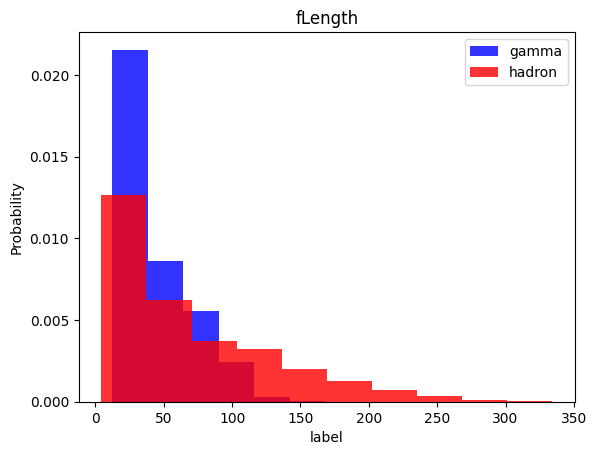

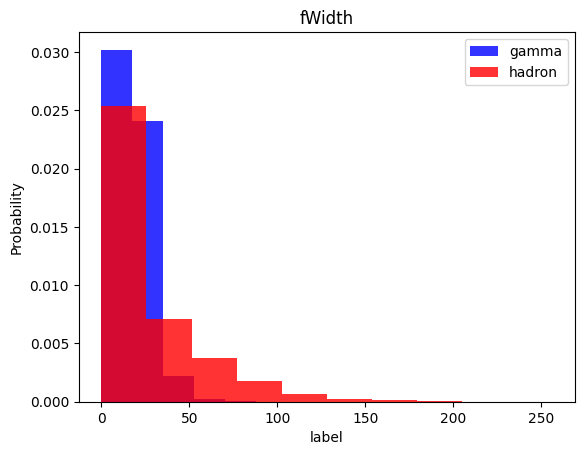

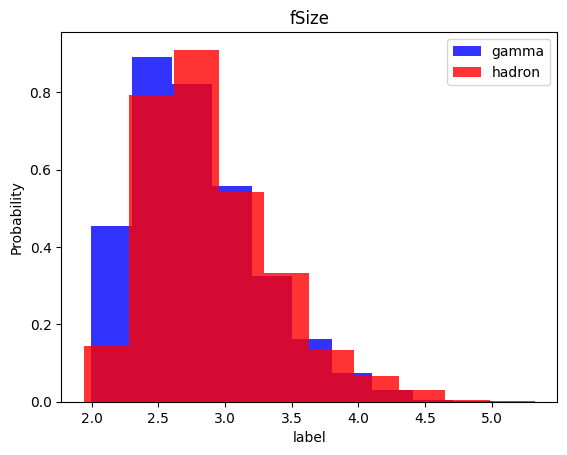

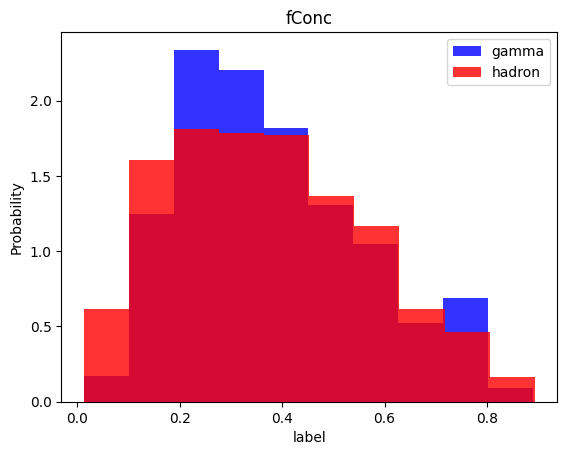

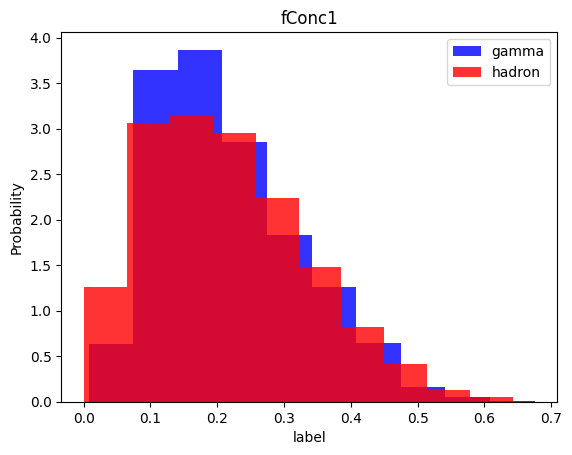

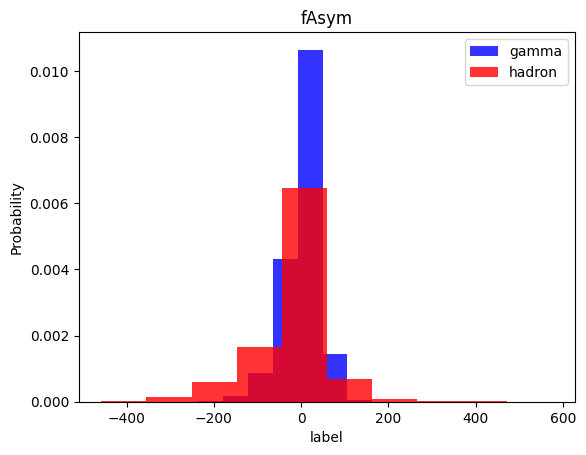

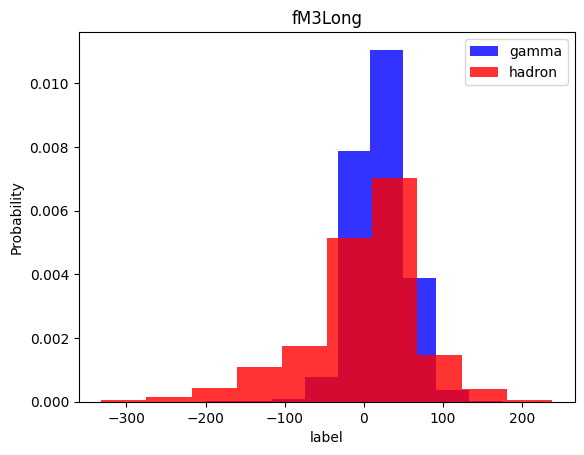

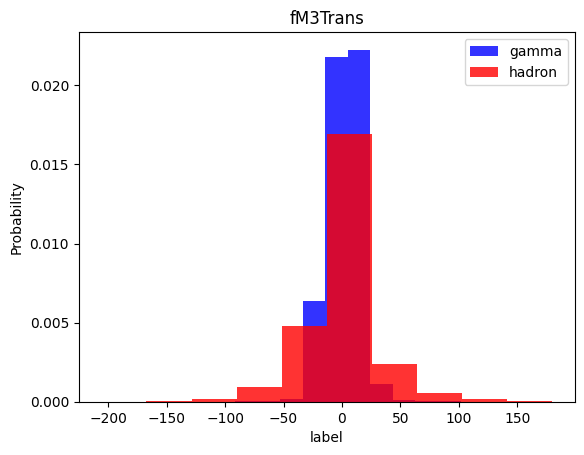

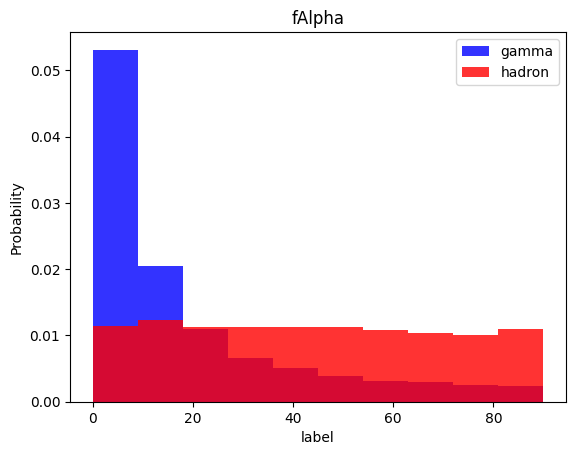

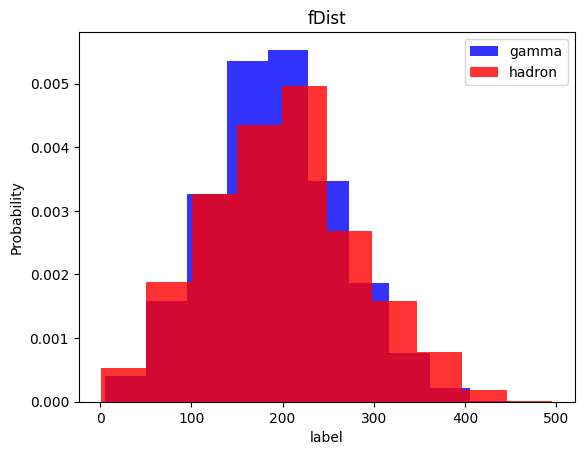

In [78]:
for label in cols[:-1]:
    plt.hist(df[df["class"] ==1] [label], color= 'blue', label= 'gamma', alpha=0.8, density=True)
    plt.hist(df[df["class"] ==0] [label], color= 'red', label= 'hadron', alpha=0.8, density=True)
    plt.title(label)
    plt.ylabel("Probability")
    plt.xlabel("label")
    plt.legend()
    plt.show()

### We are to create : Train , validation and test datasets

In [79]:
train, valid, test = np.split(df.sample(frac =1), [int(0.6*len(df)) ,int(0.8*len(df)) ])

In [80]:
def scale_dataset(dataframe):
    x = dataframe[dataframe.cols[:-1]].values
    y  =dataframe[dataframe[-1]].values

    scaler = StandardScaler()
    x = scaler.fit_transform(x)

    data = np.hstack((x,np.reshape(y, (-1, 1))))
    return data, x, y

In [84]:
print(type(train))

<class 'numpy.ndarray'>


In [85]:
print(np.sum(train[:, -1] == 1))


7382


In [88]:
print(np.sum(train[:-1]==0))

4196
